# Loan Prediction

### Data Preprocessing

In [131]:
import pandas as pd
df = pd.read_csv('data/Loan Dataset.csv')
pd.set_option('display.max_columns', None)

df

,age,gender,marital_status,education_level,annual_income,monthly_income,employment_status,debt_to_income_ratio,credit_score,loan_amount,loan_purpose,interest_rate,loan_term,installment,grade_subgrade,num_of_open_accounts,total_credit_limit,current_balance,delinquency_history,public_records,num_of_delinquencies,loan_paid_back
0,59,Male,Married,Master's,24240.19,2020.02,Employed,0.074,743,17173.72,Car,13.39,36,581.88,B5,7,40833.47,24302.07,1,0,1,1
1,72,Female,Married,Bachelor's,20172.98,1681.08,Employed,0.219,531,22663.89,Debt consolidation,17.81,60,573.17,F1,5,27968.01,10803.01,1,0,3,1
2,49,Female,Single,High School,26181.80,2181.82,Employed,0.234,779,3631.36,Business,9.53,60,76.32,B4,2,15502.25,4505.44,0,0,0,1
3,35,Female,Single,High School,11873.84,989.49,Employed,0.264,809,14939.23,Other,7.99,36,468.07,A5,7,18157.79,5525.63,4,0,5,1
4,63,Other,Single,Other,25326.44,2110.54,Employed,0.260,663,16551.71,Car,15.20,60,395.50,D5,1,17467.56,3593.91,2,0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,39,Female,Married,Bachelor's,39640.08,3303.34,Employed,0.275,691,16322.23,Debt consolidation,15.05,36,566.22,C5,2,23748.10,5801.45,1,0,4,0
19996,66,Female,Married,Bachelor's,32062.90,2671.91,Employed,0.367,758,16697.34,Debt consolidation,11.89,36,553.71,B5,8,49929.65,40901.31,3,0,3,1
19997,65,Female,Single,Master's,18642.02,1553.50,Student,0.106,751,23924.78,Debt consolidation,10.06,36,772.66,B4,3,13137.57,5075.67,1,0,2,1
19998,35,Male,Married,Master's,22181.39,1848.45,Retired,0.275,646,16920.13,Other,16.06,36,595.36,D2,5,19580.82,3876.16,4,0,5,1


Defining the types of column

In [132]:
target_column = 'loan_paid_back'
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
numerical_cols = df.select_dtypes(include=['int64', 'float64']).drop(target_column, axis = 1).columns.tolist()

Encoding the data

In [133]:
from sklearn.preprocessing import OneHotEncoder
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
encoder.fit(df[categorical_cols])
encoded_cols = list(encoder.get_feature_names_out(categorical_cols))
df_encoded = pd.DataFrame(encoder.transform(df[categorical_cols]),columns=encoded_cols)
df = pd.concat([df[numerical_cols], df_encoded, df[target_column]], axis=1)
pd.set_option('display.max_columns', None)
df

,age,annual_income,monthly_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,loan_term,installment,num_of_open_accounts,total_credit_limit,current_balance,delinquency_history,public_records,num_of_delinquencies,gender_Female,gender_Male,gender_Other,marital_status_Divorced,marital_status_Married,marital_status_Single,marital_status_Widowed,education_level_Bachelor's,education_level_High School,education_level_Master's,education_level_Other,education_level_PhD,employment_status_Employed,employment_status_Retired,employment_status_Self-employed,employment_status_Student,employment_status_Unemployed,loan_purpose_Business,loan_purpose_Car,loan_purpose_Debt consolidation,loan_purpose_Education,loan_purpose_Home,loan_purpose_Medical,loan_purpose_Other,loan_purpose_Vacation,grade_subgrade_A1,grade_subgrade_A2,grade_subgrade_A3,grade_subgrade_A4,grade_subgrade_A5,grade_subgrade_B1,grade_subgrade_B2,grade_subgrade_B3,grade_subgrade_B4,grade_subgrade_B5,grade_subgrade_C1,grade_subgrade_C2,grade_subgrade_C3,grade_subgrade_C4,grade_subgrade_C5,grade_subgrade_D1,grade_subgrade_D2,grade_subgrade_D3,grade_subgrade_D4,grade_subgrade_D5,grade_subgrade_E1,grade_subgrade_E2,grade_subgrade_E3,grade_subgrade_E4,grade_subgrade_E5,grade_subgrade_F1,grade_subgrade_F2,grade_subgrade_F3,grade_subgrade_F4,grade_subgrade_F5,loan_paid_back
0,59,24240.19,2020.02,0.074,743,17173.72,13.39,36,581.88,7,40833.47,24302.07,1,0,1,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
1,72,20172.98,1681.08,0.219,531,22663.89,17.81,60,573.17,5,27968.01,10803.01,1,0,3,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1
2,49,26181.80,2181.82,0.234,779,3631.36,9.53,60,76.32,2,15502.25,4505.44,0,0,0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
3,35,11873.84,989.49,0.264,809,14939.23,7.99,36,468.07,7,18157.79,5525.63,4,0,5,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
4,63,25326.44,2110.54,0.260,663,16551.71,15.20,60,395.50,1,17467.56,3593.91,2,0,2,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,39,39640.08,3303.34,0.275,691,16322.23,15.05,36,566.22,2,23748.10,5801.45,1,0,4,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
19996,66,32062.90,2671.91,0.367,758,16697.34,11.89,36,553.71,8,49929.65,40901.31,3,0,3,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
19997,65,18642.02,1553.50,0.106,751,23924.78,10.06,36,772.66,3,13137.57,5075.67,1,0,2,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.

Scaling the data

RobustScaler

In [134]:
robust_cols = ['annual_income', 'monthly_income', 'loan_amount', 'current_balance', 'total_credit_limit', 'total_credit_limit']
from sklearn.preprocessing import RobustScaler
rc = RobustScaler().fit(df[robust_cols])
df[robust_cols] = rc.transform(df[robust_cols])
df.describe()

,age,annual_income,monthly_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,loan_term,installment,num_of_open_accounts,total_credit_limit,current_balance,delinquency_history,public_records,num_of_delinquencies,gender_Female,gender_Male,gender_Other,marital_status_Divorced,marital_status_Married,marital_status_Single,marital_status_Widowed,education_level_Bachelor's,education_level_High School,education_level_Master's,education_level_Other,education_level_PhD,employment_status_Employed,employment_status_Retired,employment_status_Self-employed,employment_status_Student,employment_status_Unemployed,loan_purpose_Business,loan_purpose_Car,loan_purpose_Debt consolidation,loan_purpose_Education,loan_purpose_Home,loan_purpose_Medical,loan_purpose_Other,loan_purpose_Vacation,grade_subgrade_A1,grade_subgrade_A2,grade_subgrade_A3,grade_subgrade_A4,grade_subgrade_A5,grade_subgrade_B1,grade_subgrade_B2,grade_subgrade_B3,grade_subgrade_B4,grade_subgrade_B5,grade_subgrade_C1,grade_subgrade_C2,grade_subgrade_C3,grade_subgrade_C4,grade_subgrade_C5,grade_subgrade_D1,grade_subgrade_D2,grade_subgrade_D3,grade_subgrade_D4,grade_subgrade_D5,grade_subgrade_E1,grade_subgrade_E2,grade_subgrade_E3,grade_subgrade_E4,grade_subgrade_E5,grade_subgrade_F1,grade_subgrade_F2,grade_subgrade_F3,grade_subgrade_F4,grade_subgrade_F5,loan_paid_back
count,20000.000000,2.000000e+04,20000.000000,20000.000000,20000.00000,20000.000000,20000.000000,20000.00000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.00000,20000.000000,20000.000000,20000.000000,20000.000000,20000.00000,20000.000000,20000.000000,20000.00000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.00000,20000.000000,20000.00000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,48.027000,2.289621e-01,0.228963,0.177019,679.25695,0.015077,12.400626,43.22280,455.625794,5.011800,0.253406,0.270819,1.990150,0.061800,2.489150,0.50170,0.476800,0.021500,0.071400,0.448700,0.45155,0.028350,0.402250,0.29595,0.186200,0.075400,0.040200,0.650350,0.058800,0.146150,0.039050,0.105650,0.081450,0.119500,0.399050,0.083750,0.098600,0.059800,0.127500,0.030350,0.007500,0.009100,0.009300,0.008050,0.009500,0.031000,0.032700,0.029950,0.029900,0.030200,0.070500,0.071800,0.075700,0.073150,0.071100,0.057750,0.054550,0.057300,0.055000,0.053650,0.016850,0.016050,0.01730,0.018900,0.01565,0.015450,0.014950,0.014350,0.015800,0.017000,0.799900
std,15.829352,9.425132e-01,0.942513,0.105059,69.63858,0.708487,2.442729,11.00838,274.622125,2.244529,0.977174,1.007363,1.474945,0.285105,1.631384,0.50001,0.499474,0.145048,0.257498,0.497374,0.49766,0.165975,0.490364,0.45648,0.389278,0.264042,0.196433,0.476871,0.235256,0.353265,0.193719,0.307397,0.273532,0.324384,0.489715,0.277019,0.298132,0.237122,0.333541,0.171553,0.086279,0.094961,0.095989,0.089362,0.097006,0.173322,0.177855,0.170454,0.170316,0.171142,0.255994,0.258163,0.264524,0.260389,0.256998,0.233276,0.227105,0.232421,0.227986,0.225331,0.128712,0.125671,0.13039,0.136175,0.12412,0.123337,0.121356,0.118932,0.124704,0.129274,0.400085
min,21.000000,-1.005526e+00,-1.005525,0.010000,373.00000,-1.189360,3.140000,36.00000,9.430000,0.000000,-1.027216,-0.805309,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,

StandardScaler

In [135]:
standard_cols = ['debt_to_income_ratio', "interest_rate"]
from sklearn.preprocessing import StandardScaler
sc = StandardScaler().fit(df[standard_cols])
df[standard_cols] = sc.transform(df[standard_cols])
df.describe()

,age,annual_income,monthly_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,loan_term,installment,num_of_open_accounts,total_credit_limit,current_balance,delinquency_history,public_records,num_of_delinquencies,gender_Female,gender_Male,gender_Other,marital_status_Divorced,marital_status_Married,marital_status_Single,marital_status_Widowed,education_level_Bachelor's,education_level_High School,education_level_Master's,education_level_Other,education_level_PhD,employment_status_Employed,employment_status_Retired,employment_status_Self-employed,employment_status_Student,employment_status_Unemployed,loan_purpose_Business,loan_purpose_Car,loan_purpose_Debt consolidation,loan_purpose_Education,loan_purpose_Home,loan_purpose_Medical,loan_purpose_Other,loan_purpose_Vacation,grade_subgrade_A1,grade_subgrade_A2,grade_subgrade_A3,grade_subgrade_A4,grade_subgrade_A5,grade_subgrade_B1,grade_subgrade_B2,grade_subgrade_B3,grade_subgrade_B4,grade_subgrade_B5,grade_subgrade_C1,grade_subgrade_C2,grade_subgrade_C3,grade_subgrade_C4,grade_subgrade_C5,grade_subgrade_D1,grade_subgrade_D2,grade_subgrade_D3,grade_subgrade_D4,grade_subgrade_D5,grade_subgrade_E1,grade_subgrade_E2,grade_subgrade_E3,grade_subgrade_E4,grade_subgrade_E5,grade_subgrade_F1,grade_subgrade_F2,grade_subgrade_F3,grade_subgrade_F4,grade_subgrade_F5,loan_paid_back
count,20000.000000,2.000000e+04,20000.000000,2.000000e+04,20000.00000,20000.000000,2.000000e+04,20000.00000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.00000,20000.000000,20000.000000,20000.000000,20000.000000,20000.00000,20000.000000,20000.000000,20000.00000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.00000,20000.000000,20000.00000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,48.027000,2.289621e-01,0.228963,-1.712408e-16,679.25695,0.015077,9.087842e-16,43.22280,455.625794,5.011800,0.253406,0.270819,1.990150,0.061800,2.489150,0.50170,0.476800,0.021500,0.071400,0.448700,0.45155,0.028350,0.402250,0.29595,0.186200,0.075400,0.040200,0.650350,0.058800,0.146150,0.039050,0.105650,0.081450,0.119500,0.399050,0.083750,0.098600,0.059800,0.127500,0.030350,0.007500,0.009100,0.009300,0.008050,0.009500,0.031000,0.032700,0.029950,0.029900,0.030200,0.070500,0.071800,0.075700,0.073150,0.071100,0.057750,0.054550,0.057300,0.055000,0.053650,0.016850,0.016050,0.01730,0.018900,0.01565,0.015450,0.014950,0.014350,0.015800,0.017000,0.799900
std,15.829352,9.425132e-01,0.942513,1.000025e+00,69.63858,0.708487,1.000025e+00,11.00838,274.622125,2.244529,0.977174,1.007363,1.474945,0.285105,1.631384,0.50001,0.499474,0.145048,0.257498,0.497374,0.49766,0.165975,0.490364,0.45648,0.389278,0.264042,0.196433,0.476871,0.235256,0.353265,0.193719,0.307397,0.273532,0.324384,0.489715,0.277019,0.298132,0.237122,0.333541,0.171553,0.086279,0.094961,0.095989,0.089362,0.097006,0.173322,0.177855,0.170454,0.170316,0.171142,0.255994,0.258163,0.264524,0.260389,0.256998,0.233276,0.227105,0.232421,0.227986,0.225331,0.128712,0.125671,0.13039,0.136175,0.12412,0.123337,0.121356,0.118932,0.124704,0.129274,0.400085
min,21.000000,-1.005526e+00,-1.005525,-1.589801e+00,373.00000,-1.189360,-3.791194e+00,36.00000,9.430000,0.000000,-1.027216,-0.805309,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0

In [136]:
df

,age,annual_income,monthly_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,loan_term,installment,num_of_open_accounts,total_credit_limit,current_balance,delinquency_history,public_records,num_of_delinquencies,gender_Female,gender_Male,gender_Other,marital_status_Divorced,marital_status_Married,marital_status_Single,marital_status_Widowed,education_level_Bachelor's,education_level_High School,education_level_Master's,education_level_Other,education_level_PhD,employment_status_Employed,employment_status_Retired,employment_status_Self-employed,employment_status_Student,employment_status_Unemployed,loan_purpose_Business,loan_purpose_Car,loan_purpose_Debt consolidation,loan_purpose_Education,loan_purpose_Home,loan_purpose_Medical,loan_purpose_Other,loan_purpose_Vacation,grade_subgrade_A1,grade_subgrade_A2,grade_subgrade_A3,grade_subgrade_A4,grade_subgrade_A5,grade_subgrade_B1,grade_subgrade_B2,grade_subgrade_B3,grade_subgrade_B4,grade_subgrade_B5,grade_subgrade_C1,grade_subgrade_C2,grade_subgrade_C3,grade_subgrade_C4,grade_subgrade_C5,grade_subgrade_D1,grade_subgrade_D2,grade_subgrade_D3,grade_subgrade_D4,grade_subgrade_D5,grade_subgrade_E1,grade_subgrade_E2,grade_subgrade_E3,grade_subgrade_E4,grade_subgrade_E5,grade_subgrade_F1,grade_subgrade_F2,grade_subgrade_F3,grade_subgrade_F4,grade_subgrade_F5,loan_paid_back
0,59,-0.405859,-0.405856,-0.980607,743,0.183395,0.405038,36,581.88,7,0.017837,0.269405,1,0,1,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
1,72,-0.539573,-0.539573,0.399600,531,0.635403,2.214535,60,573.17,5,-0.369901,-0.340013,1,0,3,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1
2,49,-0.342026,-0.342024,0.542380,779,-0.931554,-1.175201,60,76.32,2,-0.745594,-0.624318,0,0,0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
3,35,-0.812417,-0.812415,0.827940,809,-0.000571,-1.805660,36,468.07,7,-0.665561,-0.578261,4,0,5,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
4,63,-0.370147,-0.370145,0.789866,663,0.132185,1.146031,60,395.50,1,-0.686363,-0.665469,2,0,2,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,39,0.100431,0.100431,0.932646,691,0.113292,1.084623,36,566.22,2,-0.497081,-0.565809,1,0,4,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
19996,66,-0.148678,-0.148677,1.808363,758,0.144175,-0.209045,36,553.71,8,0.291977,1.018780,3,0,3,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
19997,65,-0.589905,-0.589905,-0.676009,751,0.739213,-0.958225,36,772.66,3,-0.816860,-0.598575,1,0,2,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0

splitting the data

In [137]:
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(df[encoded_cols+numerical_cols], df[target_column], test_size=0.2, random_state=42)
X_train.shape, X_test.shape, Y_train.shape, Y_test.shape

((16000, 70), (4000, 70), (16000,), (4000,))

In [138]:
df[encoded_cols+numerical_cols]

,gender_Female,gender_Male,gender_Other,marital_status_Divorced,marital_status_Married,marital_status_Single,marital_status_Widowed,education_level_Bachelor's,education_level_High School,education_level_Master's,education_level_Other,education_level_PhD,employment_status_Employed,employment_status_Retired,employment_status_Self-employed,employment_status_Student,employment_status_Unemployed,loan_purpose_Business,loan_purpose_Car,loan_purpose_Debt consolidation,loan_purpose_Education,loan_purpose_Home,loan_purpose_Medical,loan_purpose_Other,loan_purpose_Vacation,grade_subgrade_A1,grade_subgrade_A2,grade_subgrade_A3,grade_subgrade_A4,grade_subgrade_A5,grade_subgrade_B1,grade_subgrade_B2,grade_subgrade_B3,grade_subgrade_B4,grade_subgrade_B5,grade_subgrade_C1,grade_subgrade_C2,grade_subgrade_C3,grade_subgrade_C4,grade_subgrade_C5,grade_subgrade_D1,grade_subgrade_D2,grade_subgrade_D3,grade_subgrade_D4,grade_subgrade_D5,grade_subgrade_E1,grade_subgrade_E2,grade_subgrade_E3,grade_subgrade_E4,grade_subgrade_E5,grade_subgrade_F1,grade_subgrade_F2,grade_subgrade_F3,grade_subgrade_F4,grade_subgrade_F5,age,annual_income,monthly_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,loan_term,installment,num_of_open_accounts,total_credit_limit,current_balance,delinquency_history,public_records,num_of_delinquencies
0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,59,-0.405859,-0.405856,-0.980607,743,0.183395,0.405038,36,581.88,7,0.017837,0.269405,1,0,1
1,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,72,-0.539573,-0.539573,0.399600,531,0.635403,2.214535,60,573.17,5,-0.369901,-0.340013,1,0,3
2,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,49,-0.342026,-0.342024,0.542380,779,-0.931554,-1.175201,60,76.32,2,-0.745594,-0.624318,0,0,0
3,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,35,-0.812417,-0.812415,0.827940,809,-0.000571,-1.805660,36,468.07,7,-0.665561,-0.578261,4,0,5
4,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,63,-0.370147,-0.370145,0.789866,663,0.132185,1.146031,60,395.50,1,-0.686363,-0.665469,2,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,39,0.100431,0.100431,0.932646,691,0.113292,1.084623,36,566.22,2,-0.497081,-0.565809,1,0,4
19996,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,66,-0.148678,-0.148677,1.808363,758,0.144175,-0.209045,36,553.71,8,0.291977,1.018780,3,0,3
19997,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.

### Model Selection

In [139]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
model = LogisticRegression(solver = 'liblinear').fit(X_train, Y_train)
pred = model.predict(X_train)
from sklearn.metrics import accuracy_score
print(f"The accuracy of the prediction is: {accuracy_score(pred, Y_train)*100:.2f}%")

The accuracy of the prediction is: 89.05%


Testing the model on testing data

In [140]:
pred = model.predict(X_test)
print(f"The accuracy of the prediction is: {accuracy_score(pred, Y_test)*100:.2f}%")

The accuracy of the prediction is: 88.17%


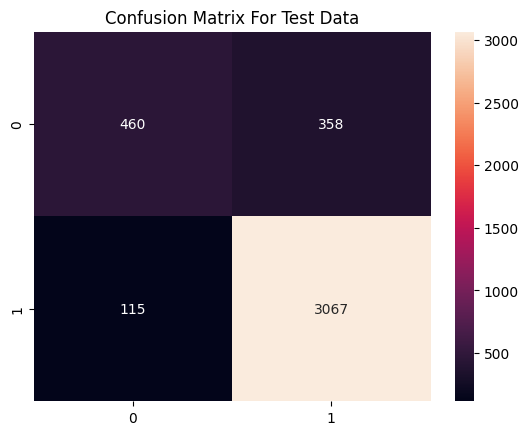

In [156]:
import seaborn as sns
sns.heatmap(confusion_matrix(Y_test, model.predict(X_test)), annot=True, fmt='d')
import matplotlib.pyplot as plt 
plt.title("Confusion Matrix For Test Data")
plt.show()

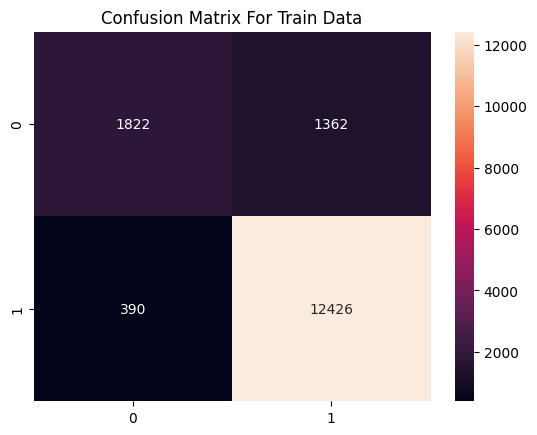

In [157]:
cf = confusion_matrix(Y_train, model.predict(X_train))
sns.heatmap(cf, annot=True, fmt='d')
plt.title("Confusion Matrix For Train Data")
plt.show()

Preparing the function to predict and make heatmap of confusion matrix

In [152]:
def predict_and_plot(inputs):
    input_df = pd.DataFrame([inputs])
    input_df[standard_cols] = sc.transform(input_df[standard_cols])
    input_df[robust_cols] = rc.transform(input_df[robust_cols])
    input_df[encoded_cols] = encoder.transform(input_df[categorical_cols])
    X_input = input_df[encoded_cols + numerical_cols]
    pred = model.predict(X_input)
    if pred[0] == 1:
        print("The loan will be paid back")
    else:
        print("The loan will not be paid back")
    print("---------------------------------------------------------------------------")
    prob = model.predict_proba(X_input)
    print(f"The probability of the loan being paid back is: {prob[0][1]*100:.2f}%")

In [153]:
predict_and_plot({
        "age": 41,
        "gender": "Male",
        "marital_status": "Single",
        "education_level": "Bachelor's",
        "annual_income": 0.1,
        "monthly_income": 0.0001,
        "employment_status": "Employed",
        "debt_to_income_ratio": 0.25,
        "credit_score": 720,
        "loan_amount": 15000,
        "loan_purpose": "Car",
        "interest_rate": 5.5,
        "loan_term": 36,
        "installment": 455.0,
        "grade_subgrade": "B2",
        "num_of_open_accounts": 5,
        "total_credit_limit": 20000,
        "current_balance": 4000,
        "delinquency_history": 0,
        "public_records": 0,
        "num_of_delinquencies": 0
    })

The loan will be paid back
---------------------------------------------------------------------------
The probability of the loan being paid back is: 94.92%


In [154]:
predict_and_plot({
    "age": 35,
    "gender": "Female",
    "marital_status": "Single",
    "education_level": "High School",
    "annual_income": 20000,       # Low annual income
    "monthly_income": 1666,       # Corresponding monthly income
    "employment_status": "Employed",
    "debt_to_income_ratio": 0.6,  # Very high debt ratio
    "credit_score": 580,          # Poor credit score
    "loan_amount": 25000,         # Large loan relative to income
    "loan_purpose": "Home Improvement",
    "interest_rate": 12.5,        # High interest rate
    "loan_term": 60,              # Long-term loan
    "installment": 700,           # Monthly installment too high for income
    "grade_subgrade": "D3",
    "num_of_open_accounts": 10,   # Too many accounts
    "total_credit_limit": 30000,
    "current_balance": 20000,     # High outstanding balance
    "delinquency_history": 2,     # History of missed payments
    "public_records": 1,          # Bankruptcy or public record
    "num_of_delinquencies": 3     # Multiple delinquencies
})

The loan will not be paid back
---------------------------------------------------------------------------
The probability of the loan being paid back is: 13.19%
